## Nous allons dans ce notebook créer des masques qui utilisent les outlines GLIMS pour superviser l'apprentissage de notre modèle. Nous voulons pouvoir utiliser ce masque qui représentera ce que nous voulons que le modèle prédise et qui aura deux classes, le Glacier pour tout ce qui se situe dans l'outline GLIMS et Autre pour tout ce qui n'est pas le glacier.

In [1]:
import geopandas as gpd
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import re
from rasterio.features import rasterize
from pathlib import Path
from glacier.data import repo_root
root = repo_root()

# Reprenons le même glacier que dans le notebook de visualisation voici il a l'air de quoi

Showing: C:\Users\pierr\Documents\GitHub\ift3710\projet_glacier\data\sentinel2\composites\alps\G010535E46167N_2019_summer.tif


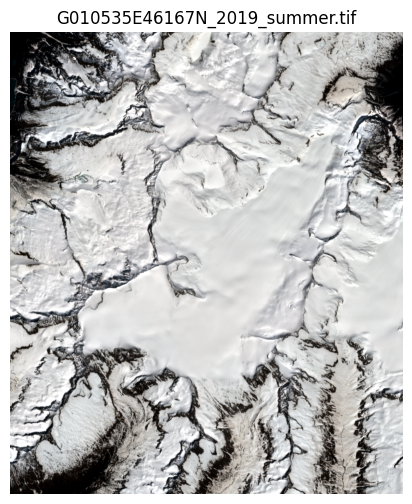

In [2]:
base = root / "data" / "sentinel2" / "composites" / "alps"
glac_id = "G010535E46167N"
year = 2019
p = base / f"{glac_id}_{year}_summer.tif"
print("Showing:", p)

da = rxr.open_rasterio(p).astype("float32")
img_crs = da.rio.crs  # on le réutilise après
# stretch simple (2-98 percentile) pour bien voir
def stretch(x):
    lo, hi = np.nanpercentile(x, 2), np.nanpercentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

blue  = stretch(da[0].values)
green = stretch(da[1].values)
red   = stretch(da[2].values)

rgb = np.stack([red, green, blue], axis=-1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title(p.name)
plt.show()

# Voici son contour GLIMS

glac_id: G010535E46167N


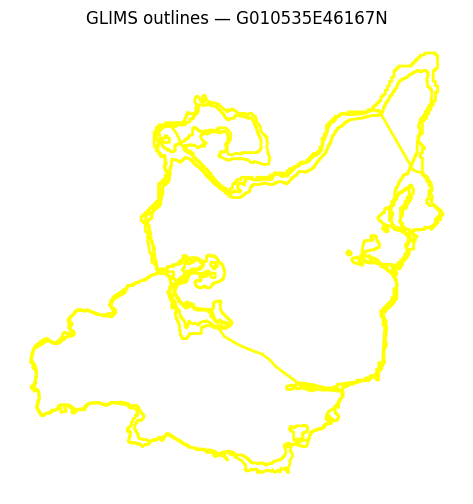

In [3]:
glac_id = p.stem.split("_")[0].strip()
print("glac_id:", glac_id)

glims = gpd.read_parquet(root / "data" / "processed" / "glims_temporal_regions.parquet")
glims["glac_id"] = glims["glac_id"].astype(str).str.strip()

if glims.crs is None:
    glims = glims.set_crs(4326)

g = glims[glims["glac_id"] == glac_id].copy()

if len(g) == 0:
    raise ValueError(f"Aucun outline GLIMS trouvé pour {glac_id}")

g = g.to_crs(img_crs)

fig, ax = plt.subplots(figsize=(6,6))
g.boundary.plot(ax=ax, color="yellow", linewidth=2)
ax.set_title(f"GLIMS outlines — {glac_id}")
ax.axis("off")
plt.show()

### Dans ce cas ci on dirait que la majorité des zones glaciaires sont déjà comprise dans le glacier en question mais parfois il semble y en avoir plusieurs sur le composites donc pour s'assurer de tous les prendre en compte 

In [4]:
year_img = int(re.search(r"_(\d{4})_summer$", p.stem).group(1))

minx, miny, maxx, maxy = da.rio.bounds()
patch_geom = box(minx, miny, maxx, maxy)

glims = gpd.read_parquet(root / "data" / "processed" / "glims_temporal_regions.parquet")
glims["glac_id"] = glims["glac_id"].astype(str).str.strip()

if glims.crs is None:
    glims = glims.set_crs(4326)

# reprojeter dans le CRS de l'image
glims = glims.to_crs(img_crs)

# garder seulement les outlines qui intersectent le patch
inter = glims[glims.intersects(patch_geom)].copy()

# filtre optionnel temporel
inter["src_year"] = inter["src_date_dt"].dt.year
inter["gap"] = (inter["src_year"] - year_img).abs()

# optionnel : rejeter les outlines trop éloignés dans le temps
MAX_GAP_YEARS = 3
inter = inter[inter["gap"] <= MAX_GAP_YEARS].copy()

if len(inter) == 0:
    raise ValueError(f"Aucun outline GLIMS à <= {MAX_GAP_YEARS} ans du composite.")


# pour chaque glacier, garder l'outline dont l'année est la plus proche
inter["src_year"] = inter["src_date_dt"].dt.year
inter["gap"] = (inter["src_year"] - year_img).abs()

inter_one = (  # gère les doublons, on veut considérer que un outline par glacier
    inter.sort_values(["glac_id", "gap"])
    .drop_duplicates("glac_id", keep="first")
    .copy()
)

print("Glaciers in patch (unique):", inter_one["glac_id"].nunique())
display(inter_one[["glac_id", "src_date_dt", "src_year", "gap"]].head())

Glaciers in patch (unique): 19


,glac_id,src_date_dt,src_year,gap
17367,G010472E46152N,2016-09-29 00:00:00+00:00,2016,3
17378,G010477E46151N,2016-09-29 00:00:00+00:00,2016,3
17387,G010485E46155N,2016-09-29 00:00:00+00:00,2016,3
17390,G010487E46149N,2016-09-29 00:00:00+00:00,2016,3
17392,G010489E46141N,2016-09-29 00:00:00+00:00,2016,3


# Voici l'image superposée par les outlines

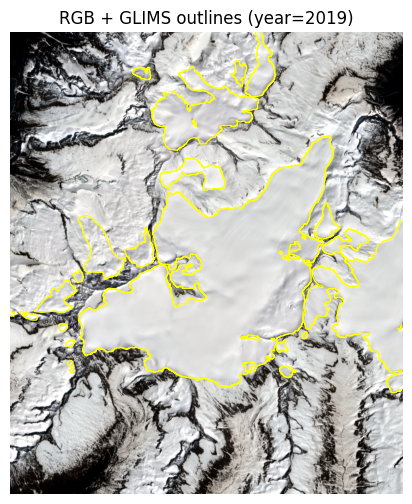

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(minx, maxx) # limite sinon si un glacier dépasse on va déssiner tout son contour
ax.set_ylim(miny, maxy)

# image géoréférencée
ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")

# contours GLIMS retenus
inter_one.boundary.plot(ax=ax, color="yellow", linewidth=1)

ax.set_title(f"RGB + GLIMS outlines (year={year_img})")
ax.axis("off")
plt.show()

# Maintenant, le masque final, ce que nous voulons que le modèle apprenne à prédire !

In [6]:
transform = da.rio.transform()
H, W = da.rio.height, da.rio.width

inter_mask = inter_one.clip(patch_geom)

shapes = [
    (geom, 1)
    for geom in inter_mask.geometry
    if geom is not None and not geom.is_empty
]

mask = rasterize(
    shapes=shapes,
    out_shape=(H, W),
    transform=transform,
    fill=0,
    dtype="uint8",
)

print("Mask shape:", mask.shape)
print("Glacier pixels:", mask.sum())

Mask shape: (1001, 850)
Glacier pixels: 228309


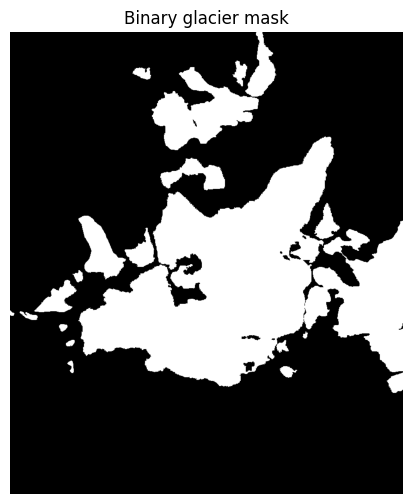

In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Binary glacier mask")
plt.axis("off")
plt.show()

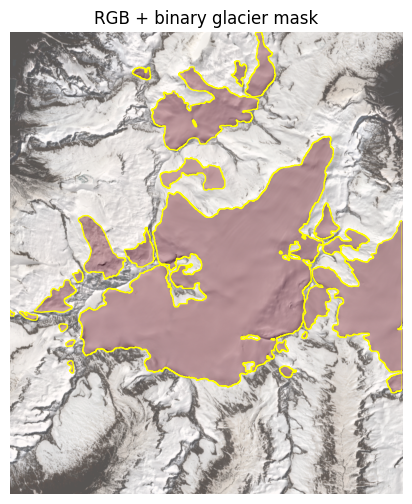

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")
ax.imshow(
    mask,
    extent=[minx, maxx, miny, maxy],
    origin="upper",
    alpha=0.35,
    cmap="Reds"
)

inter_mask.boundary.plot(ax=ax, color="yellow", linewidth=1)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("RGB + binary glacier mask")
ax.axis("off")
plt.show()

# Tout semble bien fonctionner, on a alors réutiliseer cette logique pour faire la fonction glims_mask_for_composite que nous appliquerons à toutes nos données dans data_fetch_clean afin de créer le data set qui nous permettera de valider les prédictions faites par notre model.